# Data Analysis

Analysis of the run logs in `results/logs/`.

Disk layout:

```
results/logs/<goal_dir>/<algorithm>/<algo>_<maze>_<timestamp>.json
    goal_dir   : one_goal | two_goals | three_goals | four_goals
    algorithm  : astar | dstar_lite
```

Each JSON is a single run: scalars (moves, times, replanning...) plus
structures (`wall_matrix`/`visit_matrix`, `replanning_events` list, `scenario`
with the goals). The same (goal_dir, algorithm, maze) combination may have
several runs with different timestamps — all are kept.

In [23]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

sns.set_theme(style="dark", context="notebook")

LOGS_DIR = Path.cwd().parent / "results" / "logs"

# Scalar fields -> DataFrame columns. Structures (wall_matrix, visit_matrix,
# replanning_events, scenario) stay out: fetched from raw_logs via run_id.
SCALAR_FIELDS = [
    "algorithm",
    "maze",
    "goal_count",
    "timestamp",
    "total_moves",
    "forward_moves",
    "turns",
    "distinct_cells_visited",
    "total_visits",
    "execution_time_s",
    "total_replanning_events",
    "cumulative_planning_time_s",
    "cumulative_nodes_expanded",
]

rows, raw_logs = [], {}

for path in sorted(LOGS_DIR.rglob("*.json")):
    log = json.loads(path.read_text())
    goal_dir = path.relative_to(LOGS_DIR).parts[0]   # one_goal, two_goals, ...
    # The -k sweep saves k=1..4 under the SAME filename in different goal
    # folders, so path.stem is NOT unique: goal_dir must be part of run_id.
    run_id = f"{goal_dir}/{path.stem}"
    raw_logs[run_id] = log                    # full JSON (matrices, events, scenario)
    rows.append({
        "run_id":   run_id,
        "goal_dir": goal_dir,
        **{f: log.get(f) for f in SCALAR_FIELDS},
    })

runs = pd.DataFrame(rows).set_index("run_id")
runs = runs.sort_values(["goal_count", "maze", "algorithm", "timestamp"])

print(f"runs loaded: {len(runs)}")
print("algorithms:", sorted(runs['algorithm'].unique()))
print("mazes:     ", sorted(runs['maze'].unique()))
print("goals:     ", sorted(runs['goal_count'].unique()))
runs.head()

runs loaded: 440
algorithms: ['astar', 'dstar_lite']
mazes:      ['00japan', '1stworld', '2008japan', '2008robotic', '2009japan', '2011robotic', '2011uk-techfest', '2012japan-eq', '2012uk-techfest', '2013apec', '2013japan', '2014apec', '2014japan', '2015apec', '2015japan', '2016apec', '2017apec', '2017japan', '2018apec', '82japx', '82us', '83jap', '83us', '84japx', '85japx', '85usa', '86', '86jap', '86us', '87iee', '87sin', '88iee', '88jap', '88lon', '88mtl', '88sin', '88us', '89ape', '89iee', '89sina1', '90lon', '90tor', '91hon', '91japq', '91tor', '92bos', '92lon', '93apec', '93japx', '96japx', 'j1', 'loop', 'museum', 'test1', 'zigzag']
goals:      [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


,goal_dir,algorithm,maze,goal_count,timestamp,total_moves,forward_moves,turns,distinct_cells_visited,total_visits,execution_time_s,total_replanning_events,cumulative_planning_time_s,cumulative_nodes_expanded
run_id,,,,,,,,,,,,,,
one_goal/astar_00japan_20260722_182323,one_goal,astar,00japan,1,20260722_182323,140,88,52,85,89,0.042364,35,0.011942,378
one_goal/dstar_lite_00japan_20260722_182323,one_goal,dstar_lite,00japan,1,20260722_182323,140,88,52,85,89,0.011033,34,0.002477,228
one_goal/astar_1stworld_20260722_182323,one_goal,astar,1stworld,1,20260722_182323,167,113,54,105,114,0.030546,52,0.009267,704
one_goal/dstar_lite_1stworld_20260722_182323,one_goal,dstar_lite,1stworld,1,20260722_182323,167,113,54,105,114,0.013059,37,0.002500,366
one_goal/astar_2008japan_20260722_182323,one_goal,astar,2008japan,1,20260722_182323,253,168,85,154,169,0.042942,68,0.014883,2622


## Computational cost of replanning

A\* vs D\*-Lite cost of replanning, aggregated across all mazes and grouped by
number of goals *k*. Each bar is the mean across mazes; the error bars (see
legend) are the standard deviation across mazes — dispersion from maze
difficulty, not measurement noise (runs are deterministic).

Metrics: `cumulative_nodes_expanded` (left) and `cumulative_planning_time_s`
(right).

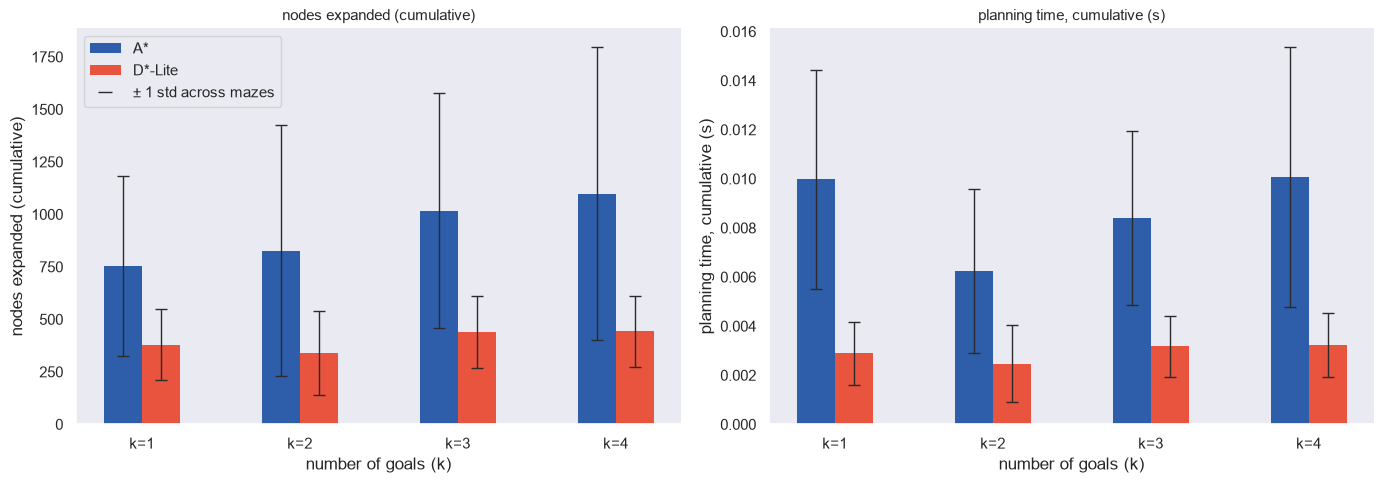

In [24]:
# One value per (maze, algorithm, k), aggregating repeated runs with the MEDIAN.
# For deterministic metrics (nodes, moves, ...) this is a no-op: repeated runs
# are identical. For wall-clock times it smooths system-load outliers.
per_cell = runs.reset_index().groupby(
    ["maze", "algorithm", "goal_count"], as_index=False
).median(numeric_only=True)

ALGO_ORDER = ["astar", "dstar_lite"]
ALGO_LABEL = {"astar": "A*", "dstar_lite": "D*-Lite"}
ALGO_COLOR = {"astar": "#2E5EAA", "dstar_lite": "#E8543E"}
ERROR_BAR_COLOR = "#2b2b2b"


def grouped_bars_by_k(metric, ylabel, ax=None, legend=True):
    """Side-by-side A*/D*-Lite bars for each k: mean across mazes, error bars = std across mazes."""
    ks = sorted(per_cell["goal_count"].unique())
    stat = per_cell.groupby(["goal_count", "algorithm"])[metric].agg(["mean", "std"])
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(ks))
    width = 0.24
    for i, algo in enumerate(ALGO_ORDER):
        means = [stat["mean"].get((k, algo), np.nan) for k in ks]
        stds = [stat["std"].get((k, algo), np.nan) for k in ks]
        ax.bar(x + (i - 0.5) * width, means, width, yerr=stds, capsize=4,
            error_kw=dict(ecolor=ERROR_BAR_COLOR, elinewidth=1.0), edgecolor="#ffffff00",
            label=ALGO_LABEL[algo], color=ALGO_COLOR[algo])
    ax.set_xticks(x)
    ax.set_xticklabels([f"k={k}" for k in ks])
    ax.set_xlabel("number of goals (k)")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontsize=11)
    handles, labels = ax.get_legend_handles_labels()
    handles.append(mlines.Line2D([], [], color=ERROR_BAR_COLOR, marker="_",
                                  linestyle="None", markersize=10))
    labels.append("± 1 std across mazes")
    if legend:
        ax.legend(handles, labels)
    sns.despine(ax=ax)
    return ax


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
grouped_bars_by_k("cumulative_nodes_expanded", "nodes expanded (cumulative)", ax=axes[0])
grouped_bars_by_k("cumulative_planning_time_s", "planning time, cumulative (s)", ax=axes[1], legend=False)
plt.tight_layout()
plt.show()

**Observation**: D\*-Lite expands fewer nodes but takes more planning time —
its incremental machinery (priority queue over `g`/`rhs` keys, updates) has a
much higher constant overhead per node. Time is wall-clock and
implementation-dependent; `cumulative_nodes_expanded` remains the
algorithm-intrinsic measure.

### Nodes expanded vs residual distance

Per-event relationship between search cost (`nodes_expanded`) and residual
distance to the goal (`residual_distance`), one facet per number of goals *k*
(single row, k = 1..4). Only the **dense band** (residual distance ≤ 30) is
kept — beyond that, events are too few (double digits) for a reliable mean; a
least-squares linear trend (`order=1`) with a 95% confidence band is
overlaid, with faint scatter showing the raw dispersion.

At every k, A\*'s slope is steeper than D\*-Lite's: A\* expands more nodes at
the same residual distance, and the gap widens further from the goal.

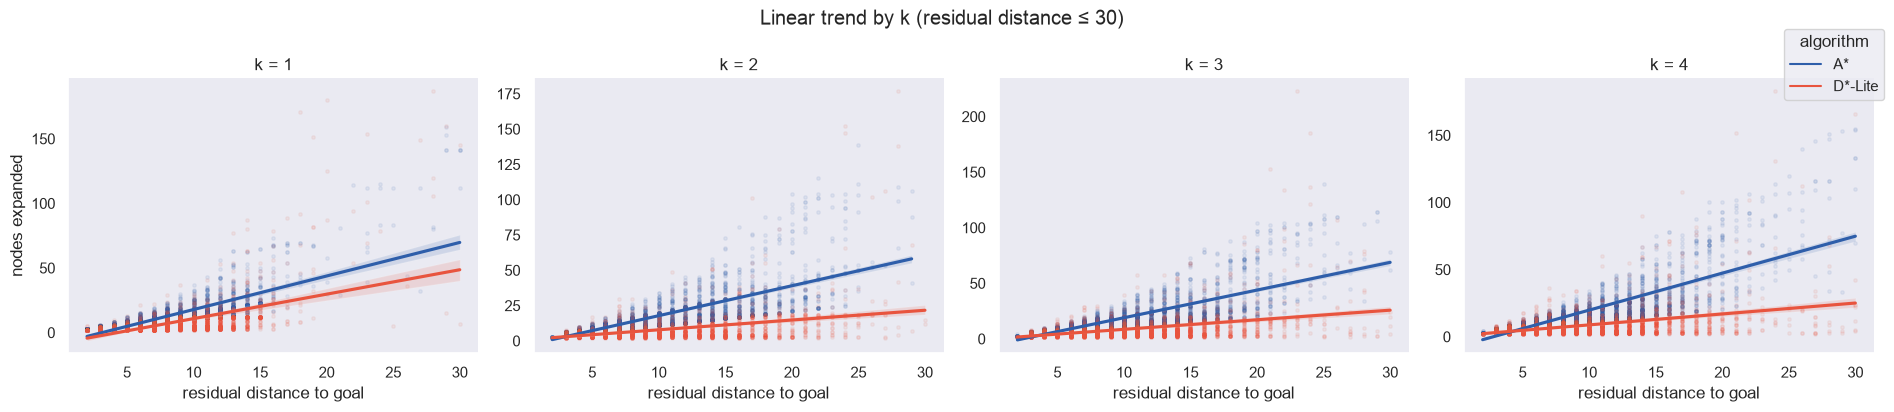

In [25]:
# Replanning events in long form: one representative run per (maze, algo, k),
# since events are deterministic and repeats would just duplicate rows.
rep_runs = runs.reset_index().drop_duplicates(
    ["maze", "algorithm", "goal_count"])["run_id"]
ev_rows = []
for rid in rep_runs:
    log = raw_logs[rid]
    for e in log["replanning_events"]:
        ev_rows.append({
            "goal_count": log["goal_count"],
            "algorithm": ALGO_LABEL[log["algorithm"]],
            "residual_distance": e["residual_distance"],
            "nodes_expanded": e["nodes_expanded"],
        })
events = pd.DataFrame(ev_rows)
events = events[events["residual_distance"] > 0]   # drop -1 (inf) and 0

# Dense band: beyond ~30 events are too few, the tail isn't reliable.
RESIDUAL_MAX = 30
dense = events[events["residual_distance"] <= RESIDUAL_MAX]

grid = sns.lmplot(
    data=dense, x="residual_distance", y="nodes_expanded",
    hue="algorithm", col="goal_count", col_wrap=4, order=1, ci=95,
    palette={"A*": ALGO_COLOR["astar"], "D*-Lite": ALGO_COLOR["dstar_lite"]},
    height=3.8, aspect=1.25, facet_kws={"sharey": False, "sharex": False},
    scatter_kws={"s": 6, "alpha": 0.08}, legend=False,
)
grid.set_axis_labels("residual distance to goal", "nodes expanded")
grid.set_titles("k = {col_name}")
legend_handles = [mlines.Line2D([], [], color=ALGO_COLOR[a], label=l)
                   for a, l in ALGO_LABEL.items()]
grid.figure.legend(handles=legend_handles, title="algorithm",
                    loc="upper right", bbox_to_anchor=(1.0, 1.05))
grid.figure.suptitle(
    f"Linear trend by k (residual distance ≤ {RESIDUAL_MAX})", y=1.08)
plt.show()

#### Aggregated across all runs

Same trend but pooling **all runs together**, without splitting by k: a single
pair of regression lines (± 95% band) summarizes the two algorithms' overall
behavior on the dense band.

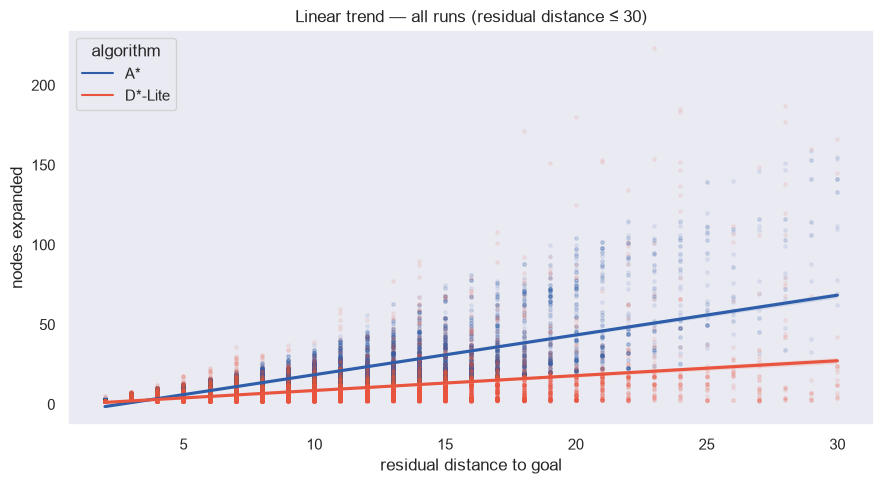

In [26]:
plt.figure(figsize=(9, 5))
for algo, label in ALGO_LABEL.items():
    sub = dense[dense["algorithm"] == label]
    sns.regplot(data=sub, x="residual_distance", y="nodes_expanded", order=1, ci=95,
                color=ALGO_COLOR[algo], scatter_kws={"s": 6, "alpha": 0.08})
handles = [mlines.Line2D([], [], color=ALGO_COLOR[a], label=l)
           for a, l in ALGO_LABEL.items()]
plt.legend(handles=handles, title="algorithm")
plt.xlabel("residual distance to goal")
plt.ylabel("nodes expanded")
plt.title(f"Linear trend — all runs (residual distance ≤ {RESIDUAL_MAX})")
plt.tight_layout()
plt.show()

### Completeness table — nodes expanded per residual-distance bin

Mean and 95% CI of nodes expanded, by residual-distance bin and algorithm, for
**all bins** (including those excluded from the regression); `in_trend` marks
the bins used in the fit (residual distance ≤ `RESIDUAL_MAX`). Beyond the
threshold `n` drops to a few dozen and the CIs widen until they overlap
between algorithms (e.g. bin 35–40); dense bins show a clear, tight-CI gap.
CI via normal approximation (z = 1.96).

In [5]:
# Mean and 95% CI (normal approximation, z=1.96) per residual-distance bin.
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, int(events["residual_distance"].max())]
ev_binned = events.assign(bin=pd.cut(events["residual_distance"], bins))

bin_table = (ev_binned.groupby(["bin", "algorithm"], observed=True)["nodes_expanded"]
             .agg(n="size", mean="mean", std="std").reset_index())
sem = bin_table["std"] / np.sqrt(bin_table["n"])
bin_table["ci95_low"] = (bin_table["mean"] - 1.96 * sem).round(1)
bin_table["ci95_high"] = (bin_table["mean"] + 1.96 * sem).round(1)
bin_table["mean"] = bin_table["mean"].round(1)
bin_table["in_trend"] = bin_table["bin"].apply(lambda b: b.right <= RESIDUAL_MAX)
bin_table = bin_table[["bin", "algorithm", "n", "mean",
                       "ci95_low", "ci95_high", "in_trend"]]
bin_table

,bin,algorithm,n,mean,ci95_low,ci95_high,in_trend
0,"(0, 5]",A*,2662,6.3,6.2,6.4,True
1,"(0, 5]",D*-Lite,2097,4.2,4.2,4.3,True
2,"(5, 10]",A*,4518,12.8,12.6,12.9,True
3,"(5, 10]",D*-Lite,3718,6.6,6.5,6.8,True
4,"(10, 15]",A*,2918,22.2,21.9,22.6,True
5,"(10, 15]",D*-Lite,2551,9.7,9.4,10.1,True
6,"(15, 20]",A*,957,36.7,35.5,37.9,True
7,"(15, 20]",D*-Lite,915,15.4,14.2,16.6,True
8,"(20, 25]",A*,286,59.4,56.0,62.7,True
9,"(20, 25]",D*-Lite,268,24.1,20.0,28.2,True


#### Markdown export

A\*/D\*-Lite pivoted side by side, ready to paste into the report (printed as
text so it's copyable).

In [6]:
# Markdown table: one row per bin, the two algorithms side by side.
def _fmt(r):
    return f"{r['mean']} [{r.ci95_low}, {r.ci95_high}] (n={r.n})"

_lines = ["| Residual distance | A\\* — mean [95% CI] | D\\*-Lite — mean [95% CI] | In trend |",
          "|---|---|---|---|"]
for b in bin_table["bin"].unique():
    sub = bin_table[bin_table["bin"] == b]
    a = sub[sub.algorithm == "A*"].iloc[0]
    d = sub[sub.algorithm == "D*-Lite"].iloc[0]
    trend = "yes" if bool(a.in_trend) else "no"
    _lines.append(f"| {b} | {_fmt(a)} | {_fmt(d)} | {trend} |")

tab_markdown = "\n".join(_lines)
print(tab_markdown)

| Residual distance | A\* — mean [95% CI] | D\*-Lite — mean [95% CI] | In trend |
|---|---|---|---|
| (0, 5] | 6.3 [6.2, 6.4] (n=2662) | 4.2 [4.2, 4.3] (n=2097) | yes |
| (5, 10] | 12.8 [12.6, 12.9] (n=4518) | 6.6 [6.5, 6.8] (n=3718) | yes |
| (10, 15] | 22.2 [21.9, 22.6] (n=2918) | 9.7 [9.4, 10.1] (n=2551) | yes |
| (15, 20] | 36.7 [35.5, 37.9] (n=957) | 15.4 [14.2, 16.6] (n=915) | yes |
| (20, 25] | 59.4 [56.0, 62.7] (n=286) | 24.1 [20.0, 28.2] (n=268) | yes |
| (25, 30] | 93.3 [84.8, 101.8] (n=72) | 35.3 [26.3, 44.3] (n=97) | yes |
| (30, 35] | 122.3 [102.1, 142.6] (n=18) | 54.8 [32.9, 76.7] (n=44) | no |
| (35, 40] | 95.4 [77.0, 113.7] (n=14) | 89.5 [63.2, 115.9] (n=19) | no |
| (40, 59] | 94.3 [81.2, 107.4] (n=17) | 84.7 [55.4, 114.0] (n=17) | no |


## Methodological note

The dataset is a full deterministic census (55 mazes × 2 algorithms × 4
values of k = 440 runs), not a random sample — repeated runs of the same
scenario produce identical deterministic scalars (moves, `replanning_events`,
`nodes_expanded`, `cost_ratio`). Inferential statistics (hypothesis tests,
p-values, confidence intervals, resampling) therefore don't apply; only
**execution/planning time** carries real measurement noise, best summarized
by median/IQR over repeated runs rather than a mean. Conclusion: descriptive
statistics and paired visual comparison only — no p-values, no resampling.